# 01 Synthetic Verify

这个 notebook 只做 Step 1 验证，不做训练。

验证内容：
- 检查 `CMDLConfig` 的 preset 与 override 调用
- 检查 `generate_cmdl_synthetic` 的输出 shape、范围与 NaN
- 对比 linear / nonlinear 两种场景
- 可视化 `z_true`、`kstar_true`、proxy/static 关系以及样本时序

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

current = Path.cwd().resolve()
repo_root = next(
    (
        path
        for path in [current, *current.parents]
        if (path / "config").exists() and (path / "data").exists()
    ),
    None,
)

if repo_root is None:
    raise RuntimeError(f"Could not find repo root from {current}")

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

plt.style.use("seaborn-v0_8-darkgrid")
print(f"repo_root = {repo_root}")

repo_root = C:\DevSpace\PyDevspace\CMDL


In [2]:
from config.cmdl_config import CMDLConfig
from data.synthetic.generate import (
    generate_cmdl_synthetic,
    plot_z_vs_kstar,
    summarize_synthetic_data,
)

cfg_linear = CMDLConfig.from_domain("synthetic")
cfg_nonlinear = CMDLConfig.from_domain("synthetic", scenario="nonlinear")

cfg_df = pd.DataFrame(
    [cfg_linear.to_dict(), cfg_nonlinear.to_dict()],
    index=["linear", "nonlinear"],
)

display(cfg_df)

,domain,max_lag,d_model,n_proxies,lambda_r,temperature,n_entities,seq_length,seq_features,static_dim,noise_std,seed,scenario
linear,synthetic,10,64,3,0.1,1.0,200,30,1,2,0.15,42,linear
nonlinear,synthetic,10,64,3,0.1,1.0,200,30,1,2,0.15,42,nonlinear


In [3]:
panel_linear = generate_cmdl_synthetic(cfg_linear)
panel_nonlinear = generate_cmdl_synthetic(cfg_nonlinear)


def validate_panel(panel, cfg, scenario_name):
    checks = {
        "scenario": scenario_name,
        "x_shape_ok": tuple(panel.X_it.shape) == (cfg.n_entities, cfg.seq_length, cfg.seq_features),
        "p_shape_ok": tuple(panel.p_i.shape) == (cfg.n_entities, cfg.n_proxies),
        "s_shape_ok": tuple(panel.s_i.shape) == (cfg.n_entities, cfg.static_dim),
        "y_shape_ok": tuple(panel.Y_it.shape) == (cfg.n_entities, cfg.seq_length),
        "z_range_ok": float(panel.z_true.min()) >= 0.0 and float(panel.z_true.max()) <= 1.0,
        "kstar_range_ok": float(panel.kstar_true.min()) >= 1.0 and float(panel.kstar_true.max()) <= cfg.max_lag,
        "x_has_nan": bool(np.isnan(panel.X_it.detach().cpu().numpy()).any()),
        "p_has_nan": bool(np.isnan(panel.p_i.detach().cpu().numpy()).any()),
        "s_has_nan": bool(np.isnan(panel.s_i.detach().cpu().numpy()).any()),
        "y_has_nan": bool(np.isnan(panel.Y_it.detach().cpu().numpy()).any()),
    }
    checks["passed"] = all(
        [
            checks["x_shape_ok"],
            checks["p_shape_ok"],
            checks["s_shape_ok"],
            checks["y_shape_ok"],
            checks["z_range_ok"],
            checks["kstar_range_ok"],
            not checks["x_has_nan"],
            not checks["p_has_nan"],
            not checks["s_has_nan"],
            not checks["y_has_nan"],
        ]
    )
    return checks


shape_df = pd.DataFrame(
    {
        "X_it": [tuple(panel_linear.X_it.shape), tuple(panel_nonlinear.X_it.shape)],
        "p_i": [tuple(panel_linear.p_i.shape), tuple(panel_nonlinear.p_i.shape)],
        "s_i": [tuple(panel_linear.s_i.shape), tuple(panel_nonlinear.s_i.shape)],
        "Y_it": [tuple(panel_linear.Y_it.shape), tuple(panel_nonlinear.Y_it.shape)],
    },
    index=["linear", "nonlinear"],
)

summary_df = pd.DataFrame(
    [
        summarize_synthetic_data(panel_linear),
        summarize_synthetic_data(panel_nonlinear),
    ],
    index=["linear", "nonlinear"],
)

validation_df = pd.DataFrame(
    [
        validate_panel(panel_linear, cfg_linear, "linear"),
        validate_panel(panel_nonlinear, cfg_nonlinear, "nonlinear"),
    ]
).set_index("scenario")

display(shape_df)
display(summary_df)
display(validation_df)

assert validation_df["passed"].all()
print("All sanity checks passed.")

,X_it,p_i,s_i,Y_it
linear,"(200, 30, 1)","(200, 3)","(200, 2)","(200, 30)"
nonlinear,"(200, 30, 1)","(200, 3)","(200, 2)","(200, 30)"


,n_entities,seq_length,seq_features,z_min,z_max,kstar_min,kstar_max,proxy_mean,proxy_std
linear,200.0,30.0,1.0,0.007362,0.992376,3.0,10.0,0.602572,0.25223
nonlinear,200.0,30.0,1.0,0.007362,0.992376,1.0,10.0,0.602572,0.25223


,x_shape_ok,p_shape_ok,s_shape_ok,y_shape_ok,z_range_ok,kstar_range_ok,x_has_nan,p_has_nan,s_has_nan,y_has_nan,passed
scenario,,,,,,,,,,,
linear,True,True,True,True,True,True,False,False,False,False,True
nonlinear,True,True,True,True,True,True,False,False,False,False,True


All sanity checks passed.


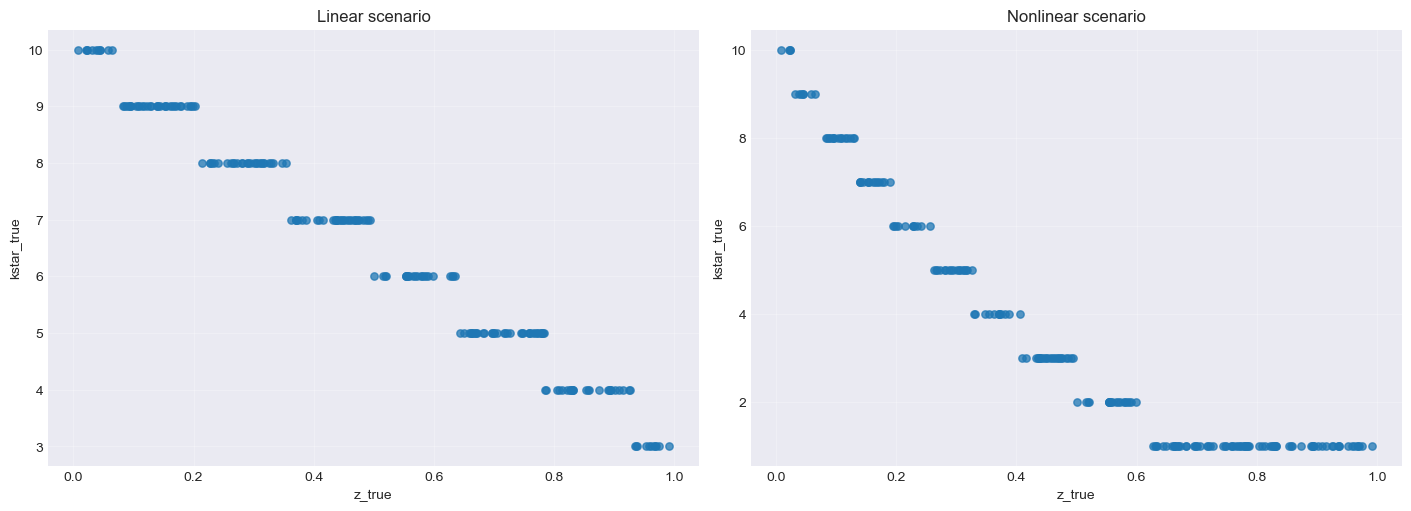

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

plot_z_vs_kstar(panel_linear, ax=axes[0])
axes[0].set_title("Linear scenario")

plot_z_vs_kstar(panel_nonlinear, ax=axes[1])
axes[1].set_title("Nonlinear scenario")

plt.show()

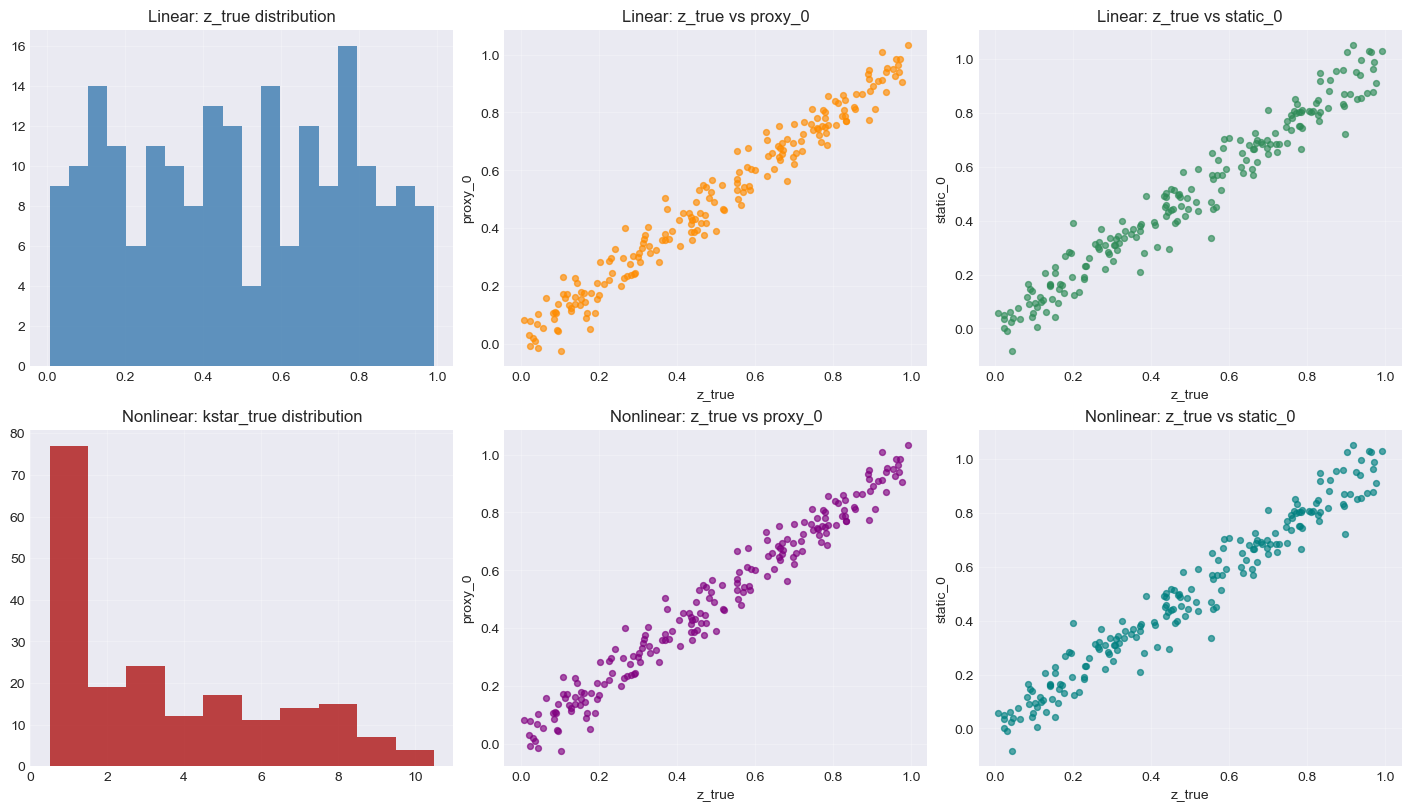

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8), constrained_layout=True)

z_linear = panel_linear.z_true.detach().cpu().numpy()
proxy_linear = panel_linear.p_i[:, 0].detach().cpu().numpy()
static_linear = panel_linear.s_i[:, 0].detach().cpu().numpy()
kstar_linear = panel_linear.kstar_true.detach().cpu().numpy()

z_nonlinear = panel_nonlinear.z_true.detach().cpu().numpy()
proxy_nonlinear = panel_nonlinear.p_i[:, 0].detach().cpu().numpy()
static_nonlinear = panel_nonlinear.s_i[:, 0].detach().cpu().numpy()
kstar_nonlinear = panel_nonlinear.kstar_true.detach().cpu().numpy()

axes[0, 0].hist(z_linear, bins=20, color="steelblue", alpha=0.85)
axes[0, 0].set_title("Linear: z_true distribution")
axes[0, 1].scatter(z_linear, proxy_linear, s=18, alpha=0.65, color="darkorange")
axes[0, 1].set_title("Linear: z_true vs proxy_0")
axes[0, 1].set_xlabel("z_true")
axes[0, 1].set_ylabel("proxy_0")
axes[0, 2].scatter(z_linear, static_linear, s=18, alpha=0.65, color="seagreen")
axes[0, 2].set_title("Linear: z_true vs static_0")
axes[0, 2].set_xlabel("z_true")
axes[0, 2].set_ylabel("static_0")

axes[1, 0].hist(kstar_nonlinear, bins=np.arange(1, cfg_nonlinear.max_lag + 2) - 0.5, color="firebrick", alpha=0.85)
axes[1, 0].set_title("Nonlinear: kstar_true distribution")
axes[1, 1].scatter(z_nonlinear, proxy_nonlinear, s=18, alpha=0.65, color="purple")
axes[1, 1].set_title("Nonlinear: z_true vs proxy_0")
axes[1, 1].set_xlabel("z_true")
axes[1, 1].set_ylabel("proxy_0")
axes[1, 2].scatter(z_nonlinear, static_nonlinear, s=18, alpha=0.65, color="teal")
axes[1, 2].set_title("Nonlinear: z_true vs static_0")
axes[1, 2].set_xlabel("z_true")
axes[1, 2].set_ylabel("static_0")

for ax in axes.flat:
    ax.grid(alpha=0.25)

plt.show()

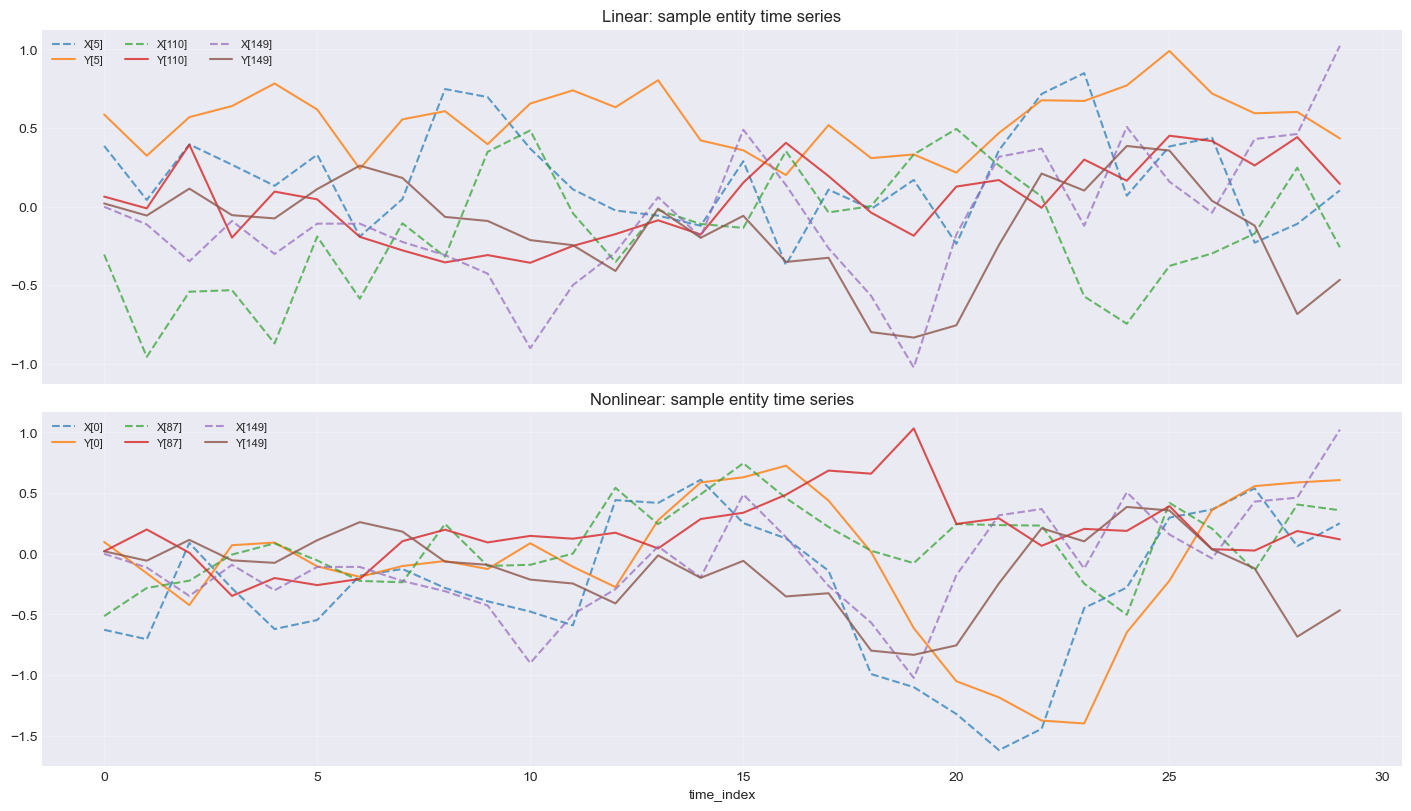

In [6]:
linear_order = np.argsort(panel_linear.kstar_true.detach().cpu().numpy())
nonlinear_order = np.argsort(panel_nonlinear.kstar_true.detach().cpu().numpy())
selected_linear = [int(linear_order[0]), int(linear_order[len(linear_order) // 2]), int(linear_order[-1])]
selected_nonlinear = [int(nonlinear_order[0]), int(nonlinear_order[len(nonlinear_order) // 2]), int(nonlinear_order[-1])]

time_index = panel_linear.time_index.detach().cpu().numpy()
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True, constrained_layout=True)

for entity_idx in selected_linear:
    axes[0].plot(time_index, panel_linear.X_it[entity_idx, :, 0].detach().cpu().numpy(), linestyle="--", alpha=0.7, label=f"X[{entity_idx}]")
    axes[0].plot(time_index, panel_linear.Y_it[entity_idx].detach().cpu().numpy(), alpha=0.8, label=f"Y[{entity_idx}]")
axes[0].set_title("Linear: sample entity time series")
axes[0].legend(ncol=3, fontsize=8)
axes[0].grid(alpha=0.25)

for entity_idx in selected_nonlinear:
    axes[1].plot(time_index, panel_nonlinear.X_it[entity_idx, :, 0].detach().cpu().numpy(), linestyle="--", alpha=0.7, label=f"X[{entity_idx}]")
    axes[1].plot(time_index, panel_nonlinear.Y_it[entity_idx].detach().cpu().numpy(), alpha=0.8, label=f"Y[{entity_idx}]")
axes[1].set_title("Nonlinear: sample entity time series")
axes[1].set_xlabel("time_index")
axes[1].legend(ncol=3, fontsize=8)
axes[1].grid(alpha=0.25)

plt.show()